In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns


In [34]:
df = pd.read_csv("C:\Data Analyst Training\Machine_learning_Project\Wather_Prediction\Machine_Learning_Project\Stock-Price\Data\TSLA.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,8/16/2016,45.098000,45.438000,44.681999,44.722000,44.722000,11335500
1,8/17/2016,44.866001,44.966000,44.560001,44.647999,44.647999,8935500
2,8/18/2016,44.764000,45.132000,44.458000,44.702000,44.702000,8572500
3,8/19/2016,44.708000,45.034000,44.506001,45.000000,45.000000,8297500
4,8/22/2016,44.834000,45.021999,44.535999,44.585999,44.585999,10327500
...,...,...,...,...,...,...,...
1253,8/9/2021,710.169983,719.030029,705.130005,713.760010,713.760010,14715300
1254,8/10/2021,713.989990,716.590027,701.880005,709.989990,709.989990,13432300
1255,8/11/2021,712.710022,715.179993,704.210022,707.820007,707.820007,9800600
1256,8/12/2021,706.340027,722.799988,699.400024,722.250000,722.250000,17459100


In [35]:
df = df.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close','Adj Close':'adj_close','Volume':'volume'})
df.head()

,date,open,high,low,close,adj_close,volume
0,8/16/2016,45.098000,45.438000,44.681999,44.722000,44.722000,11335500
1,8/17/2016,44.866001,44.966000,44.560001,44.647999,44.647999,8935500
2,8/18/2016,44.764000,45.132000,44.458000,44.702000,44.702000,8572500
3,8/19/2016,44.708000,45.034000,44.506001,45.000000,45.000000,8297500
4,8/22/2016,44.834000,45.021999,44.535999,44.585999,44.585999,10327500


In [36]:
df['date'] = pd.to_datetime(df.date)
df

,date,open,high,low,close,adj_close,volume
0,2016-08-16,45.098000,45.438000,44.681999,44.722000,44.722000,11335500
1,2016-08-17,44.866001,44.966000,44.560001,44.647999,44.647999,8935500
2,2016-08-18,44.764000,45.132000,44.458000,44.702000,44.702000,8572500
3,2016-08-19,44.708000,45.034000,44.506001,45.000000,45.000000,8297500
4,2016-08-22,44.834000,45.021999,44.535999,44.585999,44.585999,10327500
...,...,...,...,...,...,...,...
1253,2021-08-09,710.169983,719.030029,705.130005,713.760010,713.760010,14715300
1254,2021-08-10,713.989990,716.590027,701.880005,709.989990,709.989990,13432300
1255,2021-08-11,712.710022,715.179993,704.210022,707.820007,707.820007,9800600
1256,2021-08-12,706.340027,722.799988,699.400024,722.250000,722.250000,17459100


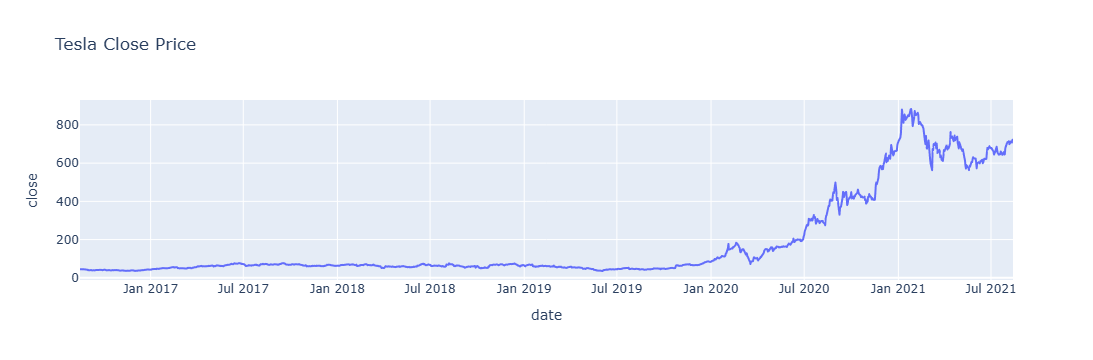

In [37]:
fig= px.line(df, x='date', y='close', title='Tesla Close Price')
fig.show()

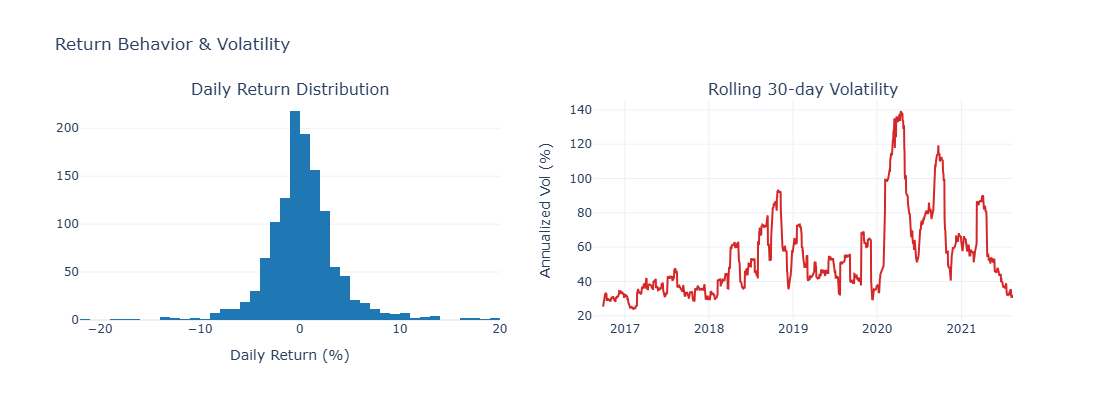

In [38]:
# --- Daily Returns distribution & volatility ---
df['daily_return'] = df['close'].pct_change()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Daily Return Distribution', 'Rolling 30-day Volatility'))
fig.add_trace(go.Histogram(x=df['daily_return'].dropna() * 100, nbinsx=80, marker_color='#1f77b4'), row=1, col=1)
roll_vol = df['daily_return'].rolling(30).std() * np.sqrt(252) * 100
fig.add_trace(go.Scatter(x=df['date'], y=roll_vol, line=dict(color='#d62728')), row=1, col=2)
fig.update_xaxes(title_text='Daily Return (%)', row=1, col=1)
fig.update_yaxes(title_text='Annualized Vol (%)', row=1, col=2)
fig.update_layout(height=400, template='plotly_white', showlegend=False,
                   title_text='Return Behavior & Volatility')
fig.show()

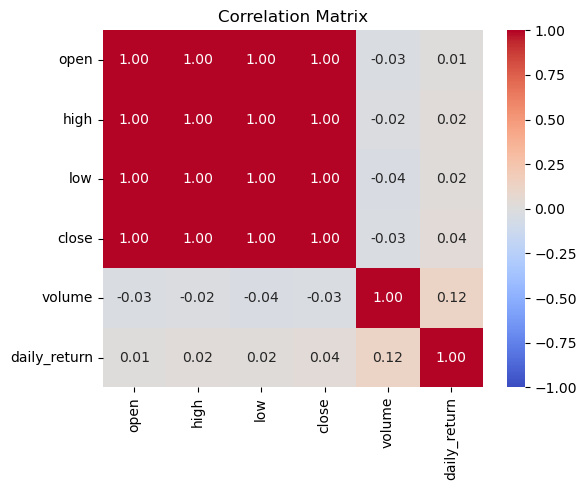

In [39]:
# --- Correlation heatmap across OHLCV + return ---
corr_cols = ['open', 'high', 'low', 'close', 'volume', 'daily_return']
plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
close_stock = df[['date','close']]
print("Shape of close dataframe:", close_stock.shape)

Shape of close dataframe: (1258, 2)


In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
close_df=scaler.fit_transform(np.array(close_stock['close']).reshape(-1,1))
print(close_df.shape)   

(1258, 1)


In [16]:
training_size=int(len(close_df)*0.70)
test_size=len(close_df)-training_size
train_data,test_data=close_df[0:training_size,:],close_df[training_size:len(close_stock),:1]
print("train_data: ", train_data.shape)
print("test_data: ", test_data.shape)

train_data:  (880, 1)
test_data:  (378, 1)


In [17]:
def create_stock_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [18]:
time_step = 17
X_train, y_train = create_stock_dataset(train_data, time_step)
X_test, y_test = create_stock_dataset(test_data, time_step)

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test", y_test.shape)

X_train:  (862, 17)
y_train:  (862,)
X_test:  (360, 17)
y_test (360,)


In [19]:
from xgboost import XGBRegressor
my_model = XGBRegressor(n_estimators=1000)
my_model.fit(X_train, y_train, verbose=True)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

predictions = my_model.predict(X_test)
print("Mean Absolute Error - MAE : " + str(mean_absolute_error(y_test, predictions)))
print("Root Mean squared Error - RMSE : " + str(math.sqrt(mean_squared_error(y_test, predictions))))

Mean Absolute Error - MAE : 0.39790856408159386
Root Mean squared Error - RMSE : 0.4742253936470222
